In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
y_test = data["y_test"]
y_ivar_test = data["y_ivar_test"]

In [4]:
from model_functions import (
    calculate_all_chi2
)

In [5]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [6]:
processed_path = Path("../data/predictions/predicciones_modelos_densos.npz")

predictions_dense = np.load(processed_path)
print(predictions_dense)

NpzFile '../data/predictions/predicciones_modelos_densos.npz' with keys: y_pred_global, y_pred_median_spec, y_pred_per_spectrum_max


In [7]:
y_pred_median_spec = predictions_dense["y_pred_median_spec"]

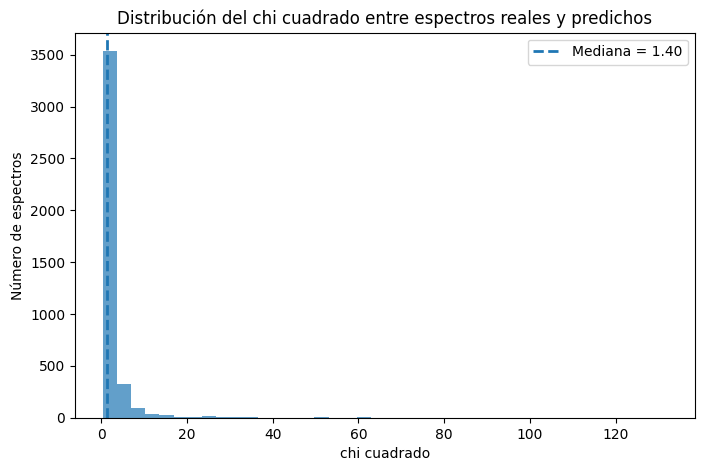

Mínimo:  0.47
Máximo:  131.91


In [8]:
chi_median = calculate_all_chi2(y_test, y_pred_median_spec, y_ivar_test, True)

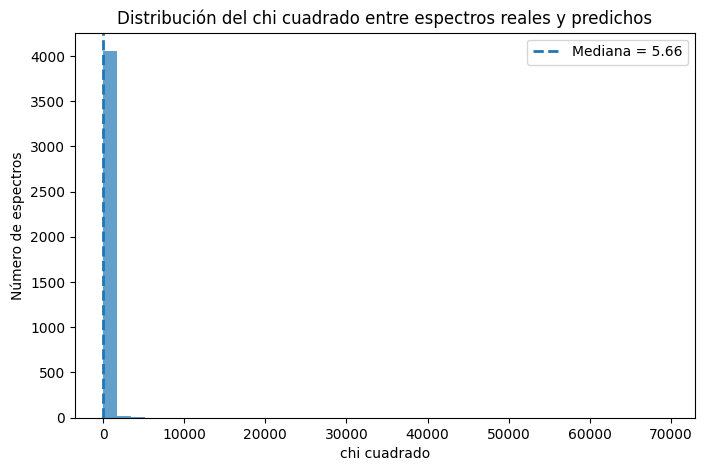

Mínimo:  0.55
Máximo:  69488.31


In [9]:
chi_median = calculate_all_chi2(y_test, predictions_dense["y_pred_per_spectrum_max"], y_ivar_test, True)

In [10]:
path_predictions_RNN = Path("../data/predictions/predicciones_modelos_RNN.npz")

predictions_RNN = np.load(path_predictions_RNN)
print(predictions_RNN)

NpzFile '../data/predictions/predicciones_modelos_RNN.npz' with keys: y_pred_birnn_attention, y_pred_birnn_simple, y_pred_spec_std


In [11]:
path_predictions_BIRNN = Path("../data/predictions/predicciones_modelos_BIRNN_2.npz")

predictions_BIRNN = np.load(path_predictions_BIRNN)
print(predictions_BIRNN)

NpzFile '../data/predictions/predicciones_modelos_BIRNN_2.npz' with keys: y_pred_spec_birnn_attention_2, y_pred_spec_birnn_simple_2


In [12]:
path_predictions_BIRNN_SMALL = Path("../data/predictions/predicciones_modelos_BIRNN_3.npz")

predictions_BIRNN_SMALL = np.load(path_predictions_BIRNN_SMALL)
print(predictions_BIRNN_SMALL)

NpzFile '../data/predictions/predicciones_modelos_BIRNN_3.npz' with keys: y_pred_spec_small


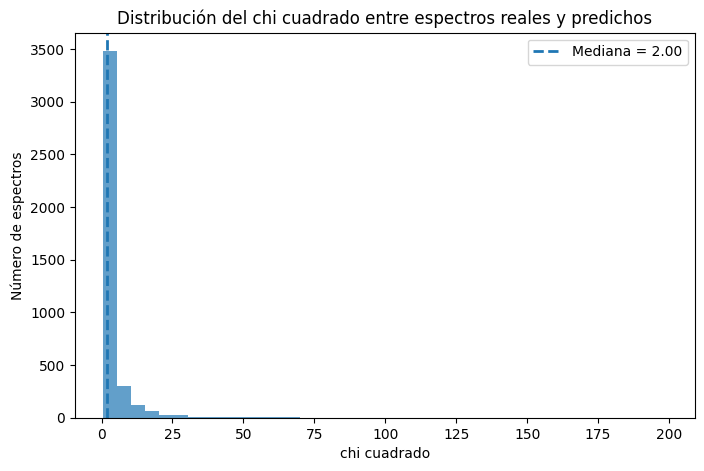

Mínimo:  0.54
Máximo:  199.19


In [13]:
chi_median = calculate_all_chi2(y_test, predictions_BIRNN["y_pred_spec_birnn_attention_2"], y_ivar_test, True)

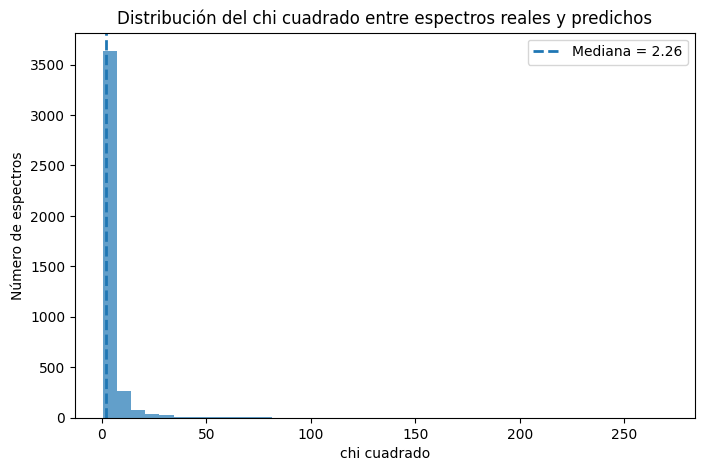

Mínimo:  0.66
Máximo:  270.30


In [14]:
chi_median = calculate_all_chi2(y_test, predictions_BIRNN["y_pred_spec_birnn_simple_2"], y_ivar_test, True)

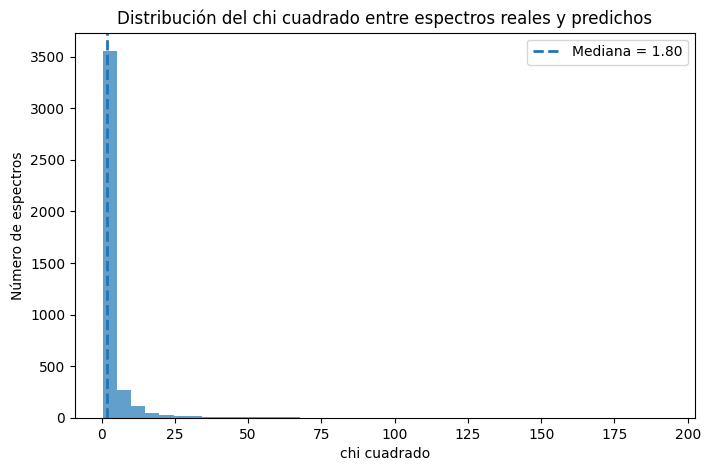

Mínimo:  0.52
Máximo:  192.86


In [15]:
chi_median = calculate_all_chi2(y_test, predictions_BIRNN_SMALL["y_pred_spec_small"], y_ivar_test, True)